# Optional Lab: 线性回归的梯度下降法

<figure>
    <center> <img src="../work/images/C1_W1_L4_S1_Lecture_GD.png"  style="width:800px;height:200px;" ></center>
</figure>

## Goals
在这个实验室中，你将：
- 使用梯度下降自动优化$w$ and $b$的过程。

## 工具
在本实验中，我们将使用：
- NumPy，一个流行的科学计算库。
- Matplotlib，一个流行的绘图数据库。
- 本地目录中 lab_utils.py 文件中的绘图例程。

In [1]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
from lab_utils_uni import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

%matplotlib widget

<a name="toc_40291_2"></a>
# 问题陈述
让我们使用与之前相同的两个数据点——一套 1000 平方英尺的房子售价为 30 万美元，一套 2000 平方英尺的房子售价为 50 万美元。

| Size (1000 sqft)     | Price (1000s of dollars) |
| ----------------| ------------------------ |
| 1               | 300                      |
| 2               | 500                      |


In [2]:
# Load our data set
x_train = np.array([1.0, 2.0])   #features
y_train = np.array([300.0, 500.0])   #target value

<a name="toc_40291_2.0.1"></a>
### 成本函数计算
这是在上一个实验室中开发的。我们在这里还会再次需要它。

In [3]:
#Function to calculate the cost
def compute_cost(x, y, w, b):
   
    m = x.shape[0] 
    cost = 0
    
    for i in range(m):
        f_wb = w * x[i] + b
        cost = cost + (f_wb - y[i])**2
    total_cost = 1 / (2 * m) * cost

    return total_cost

<a name="toc_40291_2.1"></a>
## 梯度递降总结
到目前为止，在本课程中，你已经开发了一个线性模型来进行预测$f_{w,b}(x^{(i)})$:
$$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$
在线性回归中，你利用输入的训练数据通过最小化我们的预测值$f_{w,b}(x^{(i)})$与实际数据$y^{(i)}$之间的误差度量来拟合参数$w$和$b$。这个度量被称为成本，即$J(w,b)$。在训练过程中，你对所有的训练样本$x^{(i)},y^{(i)}$测量成本。

$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 $$


在讲座中，“梯度下降”被描述为：
$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
其中，参数$w$和$b$同时更新。梯度定义为：
$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

这里“同时（simultaniously）”的意思是在更新任何参数之前先计算所有参数的偏导数。

<a name="toc_40291_2.2"></a>
## 实现梯度下降
你将为一个特征实现梯度下降算法。你将需要三个函数。
- `compute_gradient`实现上述方程（4）和（5）。
- `compute_cost`实现上述方程（2）（来自上一个实验的代码）。
- `gradient_descent`，利用`compute_gradient`和`compute_cost`。
约定：
- 包含偏导数的 Python 变量的命名遵循此模式，$\frac{\partial J(w,b)}{\partial b}$将是`dj_db`。
- w.r.t 是“关于”的意思，就像$J(wb)$关于$b$的偏导数。



<a name="toc_40291_2.3"></a>
### compute_gradient
<a name='ex-01'></a>
`compute_gradient`实现上述（4）和（5）并返回$\frac{\partial J(w,b)}{\partial w}$的偏导数和$\frac{\partial J(w,b)}{\partial b}$的偏导数。其中嵌入的注释描述了这些操作。

In [4]:
def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = x.shape[0]    
    dj_dw = 0
    dj_db = 0
    
    for i in range(m):  
        f_wb = w * x[i] + b 
        dj_dw_i = (f_wb - y[i]) * x[i] 
        dj_db_i = f_wb - y[i] 
        dj_db += dj_db_i
        dj_dw += dj_dw_i 
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db

<br/>

<img align="left" src="../work/images/C1_W1_Lab03_lecture_slopes.PNG"   style="width:340px;" > 讲座描述了梯度下降如何利用某一点处成本相对于一个参数的偏导数来更新该参数。
让我们使用我们的`compute_gradient`函数来找到并绘制成本函数相对于其中一个参数$w_0$的一些偏导数。


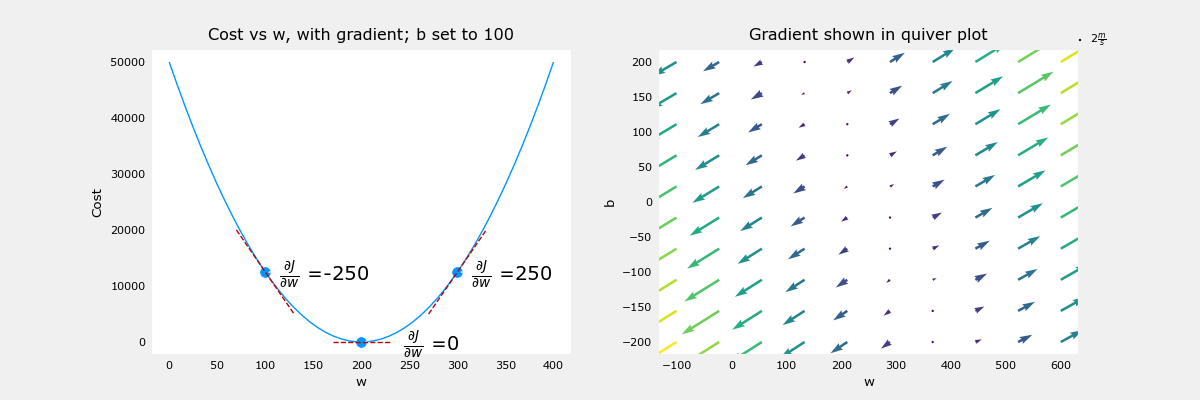

In [5]:
plt_gradients(x_train,y_train, compute_cost, compute_gradient)
plt.show()


上面，左侧的图展示了成本曲线$\frac{\partial J(w,b)}{\partial w}$ 相对于$w$在三个点处的斜率。在图的右侧，导数为正，而在左侧为负。由于 “碗状形状”，导数将始终引导梯度下降朝向底部，在那里梯度为零。
 
左侧的图将$b$固定为 100。梯度下降将同时利用$\frac{\partial J(w,b)}{\partial w}$和$\frac{\partial J(w,b)}{\partial b}$来更新参数。右侧的“矢量场图”提供了一种查看两个参数梯度的方法。箭头的大小反映了该点处梯度的大小。箭头的方向和斜率反映了该点处$\frac{\partial J(w,b)}{\partial w}$和$\frac{\partial J(w,b)}{\partial b}$的比率。

请注意，梯度指向远离最小值的方向。回顾上面的公式(3)。将缩放后的梯度从$w$或$b$的当前值中减去。这将使参数朝着降低成本的方向移动。

<a name="toc_40291_2.5"></a>
###  Gradient Descent
既然可以计算梯度，那么上面公式（3）中描述的梯度下降可以在下面的`gradient_descent`中实现。实现的细节在注释中描述。下面，你将使用这个函数在训练数据上找到$w$和$b$的最优值。

In [6]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 
    """
    Performs gradient descent to fit w,b. Updates w,b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x (ndarray (m,))  : Data, m examples 
      y (ndarray (m,))  : target values
      w_in,b_in (scalar): initial values of model parameters  
      alpha (float):     Learning rate
      num_iters (int):   number of iterations to run gradient descent
      cost_function:     function to call to produce cost
      gradient_function: function to call to produce gradient
      
    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      p_history (list): History of parameters [w,b] 
      """
    
    w = copy.deepcopy(w_in) # avoid modifying global w_in
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w , b)     

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
 
    return w, b, J_history, p_history #return w and J,w history for graphing

In [7]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 7.93e+04  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  6.500e+00, b: 4.00000e+00
Iteration 1000: Cost 3.41e+00  dj_dw: -3.712e-01, dj_db:  6.007e-01   w:  1.949e+02, b: 1.08228e+02
Iteration 2000: Cost 7.93e-01  dj_dw: -1.789e-01, dj_db:  2.895e-01   w:  1.975e+02, b: 1.03966e+02
Iteration 3000: Cost 1.84e-01  dj_dw: -8.625e-02, dj_db:  1.396e-01   w:  1.988e+02, b: 1.01912e+02
Iteration 4000: Cost 4.28e-02  dj_dw: -4.158e-02, dj_db:  6.727e-02   w:  1.994e+02, b: 1.00922e+02
Iteration 5000: Cost 9.95e-03  dj_dw: -2.004e-02, dj_db:  3.243e-02   w:  1.997e+02, b: 1.00444e+02
Iteration 6000: Cost 2.31e-03  dj_dw: -9.660e-03, dj_db:  1.563e-02   w:  1.999e+02, b: 1.00214e+02
Iteration 7000: Cost 5.37e-04  dj_dw: -4.657e-03, dj_db:  7.535e-03   w:  1.999e+02, b: 1.00103e+02
Iteration 8000: Cost 1.25e-04  dj_dw: -2.245e-03, dj_db:  3.632e-03   w:  2.000e+02, b: 1.00050e+02
Iteration 9000: Cost 2.90e-05  dj_dw: -1.082e-03, dj_db:  1.751e-03   w:  2.000e+02, b: 1.00024e+02


<img align="left" src="../work/images/C1_W1_Lab03_lecture_learningrate.PNG"  style="width:340px; padding: 15px; " > 
花一点时间，注意上面打印的梯度下降过程的一些特征。
- 成本从较大值开始，并如讲座中的幻灯片所述迅速下降。
- 偏导数 `dj_dw` 和 `dj_db` 也会变小，起初很快，然后变慢。如讲座中的图表所示，随着过程接近“碗底”，由于该点处导数的值较小，进展会变慢。
- 尽管学习率 alpha 保持不变，但进展会变慢。

### 梯度下降的成本与迭代次数
成本与迭代次数的关系图是衡量梯度下降进展的有用指标。在成功的运行中，成本应始终降低。最初成本的变化非常迅速，因此在与最终下降不同的尺度上绘制初始下降是很有用的。在下面的图中，请注意轴上成本的尺度和迭代步骤。成本与梯度下降的迭代次数的关系。

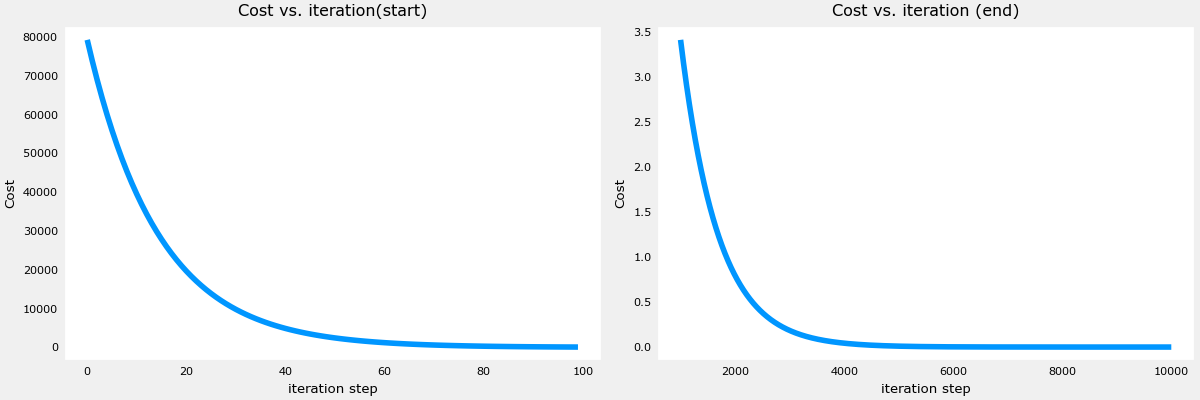

In [8]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

### 预测
既然你已经找到了参数 $w$ 和 $b$ 的最佳值，现在就可以使用该模型根据我们所学的参数来预测房屋价值。正如预期的那样，对于同一房屋，预测值几乎与训练值相同。此外，未在预测中的值与预期值一致。

In [9]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 300.0 Thousand dollars
1200 sqft house prediction 340.0 Thousand dollars
2000 sqft house prediction 500.0 Thousand dollars


<a name="toc_40291_2.6"></a>
## 绘图
在执行梯度下降的过程中，你可以通过在成本函数 $cost(w,b)$ 的等高线图上绘制每次迭代的成本来展示梯度下降的进度。

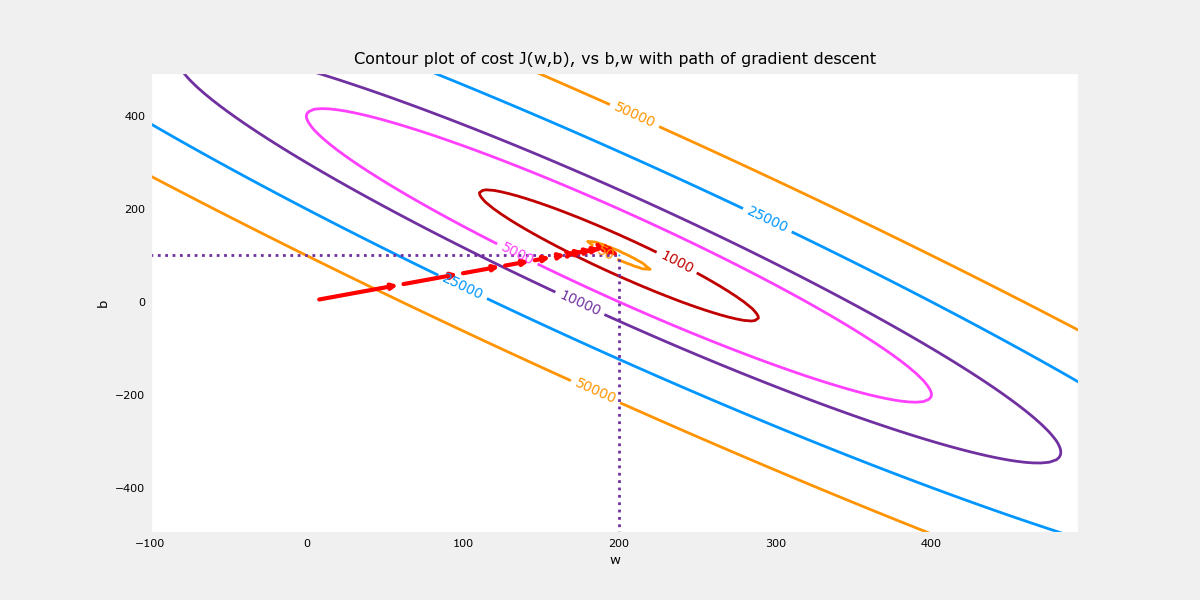

In [10]:
fig, ax = plt.subplots(1,1, figsize=(12, 6))
plt_contour_wgrad(x_train, y_train, p_hist, ax)


上面，等高线图显示了在一系列$w$和$b$上的$cost(w,b)$。成本水平由圆环表示。用红色箭头覆盖显示的是梯度下降的路径。这里有一些需要注意的事情：

- 路径朝着目标稳步（单调）前进。
- 初始步骤比接近目标的步骤大得多。

**Zooming in**, we can see that final steps of gradient descent. Note the distance between steps shrinks as the gradient approaches zero.<br/> 
**放大来看**，我们可以看到梯度下降的最后几步。注意，随着梯度接近零，步长之间的距离会缩小。

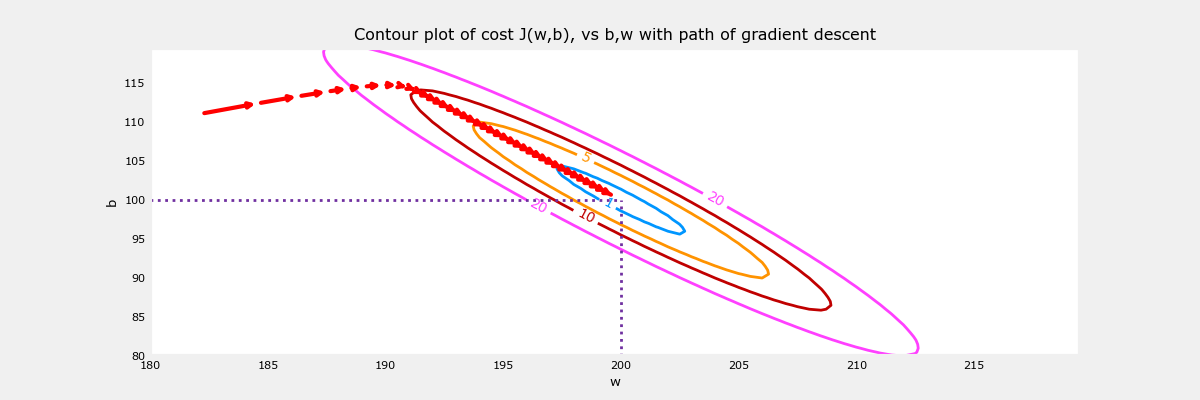

In [11]:
fig, ax = plt.subplots(1,1, figsize=(12, 4))
plt_contour_wgrad(x_train, y_train, p_hist, ax, w_range=[180, 220, 0.5], b_range=[80, 120, 0.5],
                  contours=[1, 5, 10, 20], resolution=0.5)

<a name="toc_40291_2.7.1"></a>
### Increased Learning Rate

<figure>
 <img align="left", src="../work/images/C1_W1_Lab03_alpha_too_big.PNG"   style="width:340px;height:240px;" >
</figure>

在讲座中，讨论了与方程（3）中的学习率$\alpha$的适当值相关的内容。$\alpha$越大，梯度下降就越快收敛到一个解。但是，如果$\alpha$太大，梯度下降将会发散。上面你有一个很好地收敛的解的例子。
<br/> <br/> 

让我们尝试增加$\alpha$的值，看看会发生什么：

In [12]:
# initialize parameters
w_init = 0
b_init = 0
# set alpha to a large value
iterations = 10
tmp_alpha = 8.0e-1
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)

Iteration    0: Cost 2.58e+05  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  5.200e+02, b: 3.20000e+02
Iteration    1: Cost 7.82e+05  dj_dw:  1.130e+03, dj_db:  7.000e+02   w: -3.840e+02, b:-2.40000e+02
Iteration    2: Cost 2.37e+06  dj_dw: -1.970e+03, dj_db: -1.216e+03   w:  1.192e+03, b: 7.32800e+02
Iteration    3: Cost 7.19e+06  dj_dw:  3.429e+03, dj_db:  2.121e+03   w: -1.551e+03, b:-9.63840e+02
Iteration    4: Cost 2.18e+07  dj_dw: -5.974e+03, dj_db: -3.691e+03   w:  3.228e+03, b: 1.98886e+03
Iteration    5: Cost 6.62e+07  dj_dw:  1.040e+04, dj_db:  6.431e+03   w: -5.095e+03, b:-3.15579e+03
Iteration    6: Cost 2.01e+08  dj_dw: -1.812e+04, dj_db: -1.120e+04   w:  9.402e+03, b: 5.80237e+03
Iteration    7: Cost 6.09e+08  dj_dw:  3.156e+04, dj_db:  1.950e+04   w: -1.584e+04, b:-9.80139e+03
Iteration    8: Cost 1.85e+09  dj_dw: -5.496e+04, dj_db: -3.397e+04   w:  2.813e+04, b: 1.73730e+04
Iteration    9: Cost 5.60e+09  dj_dw:  9.572e+04, dj_db:  5.916e+04   w: -4.845e+04, b:-2.99567e+04


上面，$w$和$b$ 在正负之间来回反弹，且绝对值在每次迭代中都在增加。此外，每次迭代中 $\frac{\partial J(w,b)}{\partial w}$改变符号，成本在增加而不是减少。这是一个明确的迹象，表明学习率太大，并且解正在发散。
<br/>
让我们用一个图来可视化这一点。



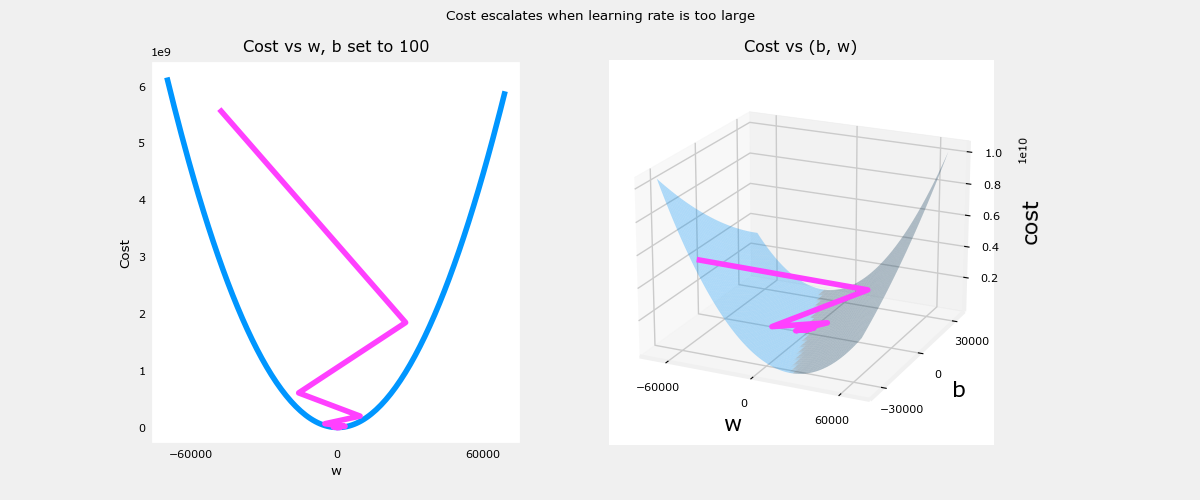

In [13]:
plt_divergence(p_hist, J_hist,x_train, y_train)
plt.show()

上面，左图显示了$w$在梯度下降最初几步中的变化过程。$w$在正负之间振荡，成本快速增长。梯度下降同时作用于$w$和$b$，所以需要右边的三维图才能看到完整的画面。


## 恭喜！
在这个实验中，你：
- 深入研究了单变量梯度下降的细节。
- 开发了一种计算梯度的程序。
- 可视化了梯度是什么。
- 完成了梯度下降程序。
- 利用梯度下降找到参数。
- 检查了调整学习率的影响。